# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [2]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

# Cargamos TODO como texto (dtype=str) a proposito: los archivos vienen sucios
# (goles como "5 goles", "N/A", fechas en varios formatos...). Si dejaramos que
# pandas adivinara los tipos, romperia esos valores. Primero limpiamos, luego tipamos.
for nombre, df in [('2018', d18), ('2022', d22), ('2026', d26)]:
    print(f'--- {nombre} ---  filas: {df.shape[0]}  columnas: {df.shape[1]}')
    print('columnas:', list(df.columns))
d18.head(3)

--- 2018 ---  filas: 50  columnas: 16
columnas: ['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']
--- 2022 ---  filas: 51  columnas: 16
columnas: ['match_id', 'WorldCup', 'stage', 'group_name', 'match_day', 'date', 'local', 'visitor', 'home_score', 'away_score', 'score_text', 'home_host', 'venue', 'city_name', 'comentario', 'source_url']
--- 2026 ---  filas: 75  columnas: 14
columnas: ['match', 'wc', 'round', 'grp', 'md', 'played_on', 'home', 'away', 'HG', 'AG', 'result_raw', 'host_h', 'host_a', 'source']


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [3]:
def perfil(df, nombre):
    """Perfilado rapido: dimensiones, nulos y valores unicos sospechosos."""
    print(f'================ {nombre} ================')
    print('Dimensiones:', df.shape)
    print('\nNulos por columna:')
    print(df.isna().sum())
    # Duplicados: la primera columna es el identificador de partido en los tres archivos.
    id_col = df.columns[0]
    print('\nFilas duplicadas por', id_col, ':', df[id_col].duplicated().sum())
    print('Filas totalmente duplicadas   :', df.duplicated().sum())
    # Buscamos las columnas de goles para ver valores que NO son numeros limpios.
    for col in df.columns:
        low = col.lower()
        if 'gol' in low or 'score' in low or col in ('HG', 'AG'):
            malos = [v for v in df[col].dropna().unique()
                     if not re.fullmatch(r'\d+', str(v).strip() or 'x')]
            if malos:
                print(f'  Goles no numericos en "{col}":', malos)
    print()

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')

================ 2018 ================
Dimensiones: (50, 16)

Nulos por columna:
ID Partido          0
Año                 0
Fase                0
Grupo               1
Jornada             0
Fecha               0
Hora                0
Equipo Local        0
Equipo Visitante    0
Goles Local         0
Goles Visitante     3
Marcador            1
Anfitrión Local     0
Estadio             0
Ciudad              0
Fuente              0
dtype: int64

Filas duplicadas por ID Partido : 2
Filas totalmente duplicadas   : 2
  Goles no numericos en "Goles Local": ['5 goles', '1 goles', '-1']

================ 2022 ================
Dimensiones: (51, 16)

Nulos por columna:
match_id       0
WorldCup       0
stage          0
group_name     1
match_day      0
date           1
local          0
visitor        0
home_score     4
away_score     0
score_text     0
home_host      0
venue          0
city_name      0
comentario    13
source_url     0
dtype: int64

Filas duplicadas por match_id : 3
Filas totalme

## Unificar nombres de columnas

In [4]:
# Cada archivo trae nombres de columna distintos (espanol, ingles, abreviados).
# Los mapeamos a un unico esquema canonico para poder unir los tres torneos.
rename_maps = {
    2018: {'ID Partido': 'partido_id', 'Año': 'mundial', 'Fase': 'fase', 'Grupo': 'grupo',
           'Jornada': 'jornada', 'Fecha': 'fecha', 'Equipo Local': 'equipo_local',
           'Equipo Visitante': 'equipo_visitante', 'Goles Local': 'goles_local',
           'Goles Visitante': 'goles_visitante', 'Marcador': 'marcador',
           'Anfitrión Local': 'anfitrion_raw', 'Fuente': 'fuente'},
    2022: {'match_id': 'partido_id', 'WorldCup': 'mundial', 'stage': 'fase', 'group_name': 'grupo',
           'match_day': 'jornada', 'date': 'fecha', 'local': 'equipo_local',
           'visitor': 'equipo_visitante', 'home_score': 'goles_local',
           'away_score': 'goles_visitante', 'score_text': 'marcador',
           'home_host': 'anfitrion_raw', 'source_url': 'fuente'},
    2026: {'match': 'partido_id', 'wc': 'mundial', 'round': 'fase', 'grp': 'grupo',
           'md': 'jornada', 'played_on': 'fecha', 'home': 'equipo_local',
           'away': 'equipo_visitante', 'HG': 'goles_local', 'AG': 'goles_visitante',
           'result_raw': 'marcador', 'host_h': 'anfitrion_raw',
           'host_a': 'anfitrion_visita_raw', 'source': 'fuente'},
}

# Esquema canónico mínimo:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]

# Nacion(es) sede de cada torneo. Nos servira para marcar al anfitrion de forma
# confiable (las banderas del archivo venian inconsistentes).
ANFITRIONES = {2018: {'Russia'}, 2022: {'Qatar'}, 2026: {'United States', 'Canada', 'Mexico'}}

# Bitacora de incidencias que iremos registrando durante la limpieza.
incidencias = []

## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [5]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    """Clave de comparacion: sin acentos, minusculas y sin signos.
    'España' -> 'espana' ; ' russia ' -> 'russia' ; 'BOSNIA & HERZEGOVINA' -> 'bosnia herzegovina'."""
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return ''
    s = unicodedata.normalize('NFKD', str(valor))          # separa letra y acento
    s = ''.join(c for c in s if not unicodedata.combining(c))  # quita el acento
    s = s.lower()
    s = re.sub(r'[^a-z0-9]+', ' ', s)                       # signos -> espacio
    return re.sub(r'\s+', ' ', s).strip()

# Diccionario clave -> nombre canonico, construido desde el catalogo.
clave_a_canonico = {clave_texto(v): c for v, c in zip(catalogo['variante'], catalogo['nombre_canonico'])}

def canonizar_equipo(valor):
    """Devuelve el nombre canonico del equipo, o None si no esta en el catalogo."""
    return clave_a_canonico.get(clave_texto(valor), None)

# Prueba rapida:
for x in ['KSA', ' russia ', 'Korea Rep.', 'Cabo Verde', 'Deutschland', 'the netherlands']:
    print(f'{x!r:20} -> {canonizar_equipo(x)}')

'KSA'                -> Saudi Arabia
' russia '           -> Russia
'Korea Rep.'         -> South Korea
'Cabo Verde'         -> Cape Verde
'Deutschland'        -> Germany
'the netherlands'    -> Netherlands


## Fechas, grupos, booleanos y marcadores

In [6]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

# Formatos de fecha que aparecen mezclados en los archivos.
FORMATOS = ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%d-%m-%y', '%m-%d-%y', '%b %d, %Y']

# Valores que significan "sin dato".
SENTINELAS = {'', 's/d', 'n/d', 'na', 'n/a', 'sin dato', 'nd', 'nan'}

def convertir_fecha(valor, mundial):
    """Convierte una fecha en cualquier formato a Timestamp.
    Clave: cuando el formato es ambiguo (12/06 vs 06/12) elegimos el candidato
    que cae DENTRO del rango de fechas del torneo."""
    if valor is None:
        return pd.NaT
    s = str(valor).strip()
    if s.lower() in SENTINELAS:
        return pd.NaT
    ini, fin = pd.Timestamp(rangos[mundial][0]), pd.Timestamp(rangos[mundial][1])
    candidatos = []
    # 1) Serial de Excel (numero como 46187): dias desde el 1899-12-30.
    if re.fullmatch(r'\d{4,6}', s):
        try:
            candidatos.append(pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(s)))
        except Exception:
            pass
    # 2) Probamos cada formato de texto.
    for f in FORMATOS:
        try:
            candidatos.append(pd.Timestamp(pd.to_datetime(s, format=f)))
        except (ValueError, TypeError):
            continue
    en_rango = [c for c in candidatos if ini <= c <= fin]
    if en_rango:
        return en_rango[0]
    return candidatos[0] if candidatos else pd.NaT

def extraer_numero(valor):
    """Primer entero que aparezca en el texto. '5 goles' -> 5 ; 'N/A' -> NaN ; '-1' -> -1."""
    if valor is None:
        return np.nan
    m = re.search(r'-?\d+', str(valor))
    return int(m.group()) if m else np.nan

def separar_marcador(valor):
    """Separa un marcador con -, –, —, :, x o X en (goles_local, goles_visitante)."""
    if valor is None:
        return np.nan, np.nan
    nums = re.findall(r'\d+', str(valor))
    if len(nums) >= 2:
        return int(nums[0]), int(nums[1])
    return np.nan, np.nan

def normalizar_grupo(valor):
    """Extrae la letra del grupo A-L. 'Grupo A' -> 'A' ; 'group-b' -> 'B' ; 's/d' -> NaN."""
    if valor is None:
        return np.nan
    s = str(valor).strip().lower()
    if s in SENTINELAS:
        return np.nan
    s = s.replace('grupo', '').replace('group', '')   # quitamos la palabra antes de buscar la letra
    m = re.search(r'[a-l]', s)
    return m.group().upper() if m else np.nan

def normalizar_booleano(valor):
    """Reconoce Si, 1, TRUE, si, yes... como verdadero; el resto falso."""
    if valor is None:
        return False
    return str(valor).strip().lower() in {'si', 'sí', '1', 'true', 'verdadero', 'x', 'yes'}

# Pruebas rapidas:
print(convertir_fecha('12/06/2026', 2026), '| serial:', convertir_fecha('46187', 2026))
print(separar_marcador('2 x 1'), separar_marcador('0 : 3'), separar_marcador('sin dato'))
print(extraer_numero('5 goles'), normalizar_grupo('group-b'), normalizar_booleano('Sí'))

2026-06-12 00:00:00 | serial: 2026-06-14 00:00:00
(2, 1) (0, 3) (nan, nan)
5 B True


## Función de limpieza reproducible

In [7]:
def limpiar_mundial(df, mundial):
    """Aplica toda la limpieza a un archivo y devuelve la tabla en el esquema canonico."""
    df = df.rename(columns=rename_maps[mundial]).copy()
    df['mundial'] = mundial

    # 1) Duplicados: mismo partido_id repetido. Confirmamos que son filas identicas
    #    y nos quedamos con la primera aparicion.
    antes = len(df)
    df = df.drop_duplicates(subset='partido_id', keep='first').copy()
    if antes - len(df):
        incidencias.append((mundial, 'duplicados_eliminados', antes - len(df)))

    # 2) Equipos -> nombre canonico. Registramos si alguno no esta en el catalogo.
    for col in ['equipo_local', 'equipo_visitante']:
        canon = df[col].map(canonizar_equipo)
        for x in df.loc[canon.isna(), col].unique():
            incidencias.append((mundial, 'equipo_sin_catalogo', x))
        df[col] = canon

    # 3) Jornada, grupo y fecha.
    df['jornada'] = df['jornada'].map(extraer_numero).astype('Int64')
    df['grupo'] = df['grupo'].map(normalizar_grupo)
    df['fecha'] = df['fecha'].map(lambda v: convertir_fecha(v, mundial))

    # 4) Goles: reparamos con el marcador segun la regla del Paso 7.
    gl = df['goles_local'].map(extraer_numero)
    gv = df['goles_visitante'].map(extraer_numero)
    marc = df['marcador'].map(separar_marcador)
    ml, mv = marc.map(lambda t: t[0]), marc.map(lambda t: t[1])

    def resolver(g, m, pid, lado):
        # a) Si el gol falta o es negativo -> usamos el marcador.
        if pd.isna(g) or g < 0:
            return m
        # b) Si ambos existen y NO coinciden -> lo documentamos y preferimos el marcador.
        if not pd.isna(m) and g != m:
            incidencias.append((mundial, f'conflicto_{lado}', pid, int(g), int(m)))
            return m
        return g

    df['goles_local'] = [resolver(a, b, p, 'local') for a, b, p in zip(gl, ml, df['partido_id'])]
    df['goles_visitante'] = [resolver(a, b, p, 'visita') for a, b, p in zip(gv, mv, df['partido_id'])]
    df['goles_local'] = pd.to_numeric(df['goles_local'], errors='coerce').astype('Int64')
    df['goles_visitante'] = pd.to_numeric(df['goles_visitante'], errors='coerce').astype('Int64')

    # 5) Inferir el grupo faltante usando los equipos (cada equipo juega en un solo grupo).
    mapa = {}
    for _, r in df.iterrows():
        if pd.notna(r['grupo']):
            mapa[r['equipo_local']] = r['grupo']
            mapa[r['equipo_visitante']] = r['grupo']
    def inferir(r):
        if pd.notna(r['grupo']):
            return r['grupo']
        g = mapa.get(r['equipo_local']) or mapa.get(r['equipo_visitante'])
        if g:
            incidencias.append((mundial, 'grupo_inferido', r['partido_id'], g))
        return g
    df['grupo'] = df.apply(inferir, axis=1)

    # 6) Anfitrion: marcamos True si el equipo es la nacion sede del torneo.
    df['local_es_anfitrion'] = df['equipo_local'].isin(ANFITRIONES[mundial])
    df['visitante_es_anfitrion'] = df['equipo_visitante'].isin(ANFITRIONES[mundial])

    # 7) Columnas derivadas.
    df['fase'] = 'Fase de grupos'  # los tres archivos son unicamente fase de grupos
    df['marcador'] = df['goles_local'].astype(str) + '-' + df['goles_visitante'].astype(str)
    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
    df['resultado_local'] = np.select(
        [df['goles_local'] > df['goles_visitante'], df['goles_local'] == df['goles_visitante']],
        ['Gana', 'Empata'], default='Pierde')
    df['puntos_local'] = df['resultado_local'].map({'Gana': 3, 'Empata': 1, 'Pierde': 0})

    cols = ['partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha', 'equipo_local',
            'equipo_visitante', 'goles_local', 'goles_visitante', 'marcador',
            'local_es_anfitrion', 'visitante_es_anfitrion', 'goles_totales',
            'diferencia_goles', 'resultado_local', 'puntos_local', 'fuente']
    return df[cols]

incidencias.clear()
limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)
print('Base integrada:', partidos.shape)
partidos.head()

Base integrada: (168, 18)


,partido_id,mundial,fase,grupo,jornada,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,marcador,local_es_anfitrion,visitante_es_anfitrion,goles_totales,diferencia_goles,resultado_local,puntos_local,fuente
0,M-2018-01,2018,Fase de grupos,A,1,2018-06-14,Russia,Saudi Arabia,5,0,5-0,True,False,5,5,Gana,3,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,Fase de grupos,A,1,2018-06-15,Egypt,Uruguay,0,1,0-1,False,False,1,-1,Pierde,0,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,Fase de grupos,B,1,2018-06-15,Morocco,Iran,0,1,0-1,False,False,1,-1,Pierde,0,https://github.com/jfjelstul/worldcup
3,M-2018-04,2018,Fase de grupos,B,1,2018-06-15,Portugal,Spain,3,3,3-3,False,False,6,0,Empata,1,https://github.com/jfjelstul/worldcup
4,M-2018-05,2018,Fase de grupos,C,1,2018-06-16,France,Australia,2,1,2-1,False,False,3,1,Gana,3,https://github.com/jfjelstul/worldcup


## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [8]:
# La limpieza no termina cuando el codigo deja de fallar: comprobamos invariantes.
conteo = partidos['mundial'].value_counts().sort_index()
assert conteo.to_dict() == {2018: 48, 2022: 48, 2026: 72}, conteo.to_dict()
assert partidos['partido_id'].duplicated().sum() == 0, 'hay partido_id duplicados'
assert (partidos['goles_local'] >= 0).all() and (partidos['goles_visitante'] >= 0).all(), 'goles negativos'
assert partidos[['equipo_local', 'equipo_visitante']].isna().sum().sum() == 0, 'equipos nulos'
assert partidos[['goles_local', 'goles_visitante']].isna().sum().sum() == 0, 'goles nulos'
assert partidos['grupo'].isna().sum() == 0, 'grupos nulos'
# El marcador debe ser coherente con los goles.
esperado = partidos['goles_local'].astype(str) + '-' + partidos['goles_visitante'].astype(str)
assert (partidos['marcador'] == esperado).all(), 'marcador inconsistente'
# Una fila por partido.
assert len(partidos) == 168

print('OK Todas las validaciones pasaron.')
print(conteo)
print('\nIncidencias registradas durante la limpieza:')
for i in incidencias:
    print(' ', i)
print('\nFechas que quedaron nulas (estaban vacias o "N/D" en el origen):')
print(partidos.loc[partidos['fecha'].isna(), ['partido_id', 'equipo_local', 'equipo_visitante']].to_string(index=False))

OK Todas las validaciones pasaron.
mundial
2018    48
2022    48
2026    72
Name: count, dtype: int64

Incidencias registradas durante la limpieza:
  (2018, 'duplicados_eliminados', 2)
  (2018, 'grupo_inferido', 'M-2018-10', 'F')
  (2018, 'grupo_inferido', 'M-2018-32', 'H')
  (2022, 'duplicados_eliminados', 3)
  (2022, 'grupo_inferido', 'M-2022-12', 'F')
  (2026, 'duplicados_eliminados', 3)
  (2026, 'grupo_inferido', 'M-2026-037', 'G')

Fechas que quedaron nulas (estaban vacias o "N/D" en el origen):
partido_id equipo_local equipo_visitante
 M-2022-31       Brazil      Switzerland
M-2026-024     Paraguay        Australia


In [9]:
# Guardamos los entregables en la carpeta salidas/.
SALIDA = Path('../salidas')
SALIDA.mkdir(exist_ok=True)

partidos.to_csv(SALIDA / 'base_limpia_168.csv', index=False, encoding='utf-8-sig')

# Bitacora de incidencias en formato tabla.
bitacora = pd.DataFrame([{
    'mundial': i[0], 'tipo': i[1],
    'detalle': ' | '.join(str(x) for x in i[2:])
} for i in incidencias])
bitacora.to_csv(SALIDA / 'bitacora_incidencias.csv', index=False, encoding='utf-8-sig')

print('Guardado en salidas/:')
print('  base_limpia_168.csv       ->', len(partidos), 'partidos')
print('  bitacora_incidencias.csv  ->', len(bitacora), 'incidencias')
bitacora

Guardado en salidas/:
  base_limpia_168.csv       -> 168 partidos
  bitacora_incidencias.csv  -> 7 incidencias


,mundial,tipo,detalle
0,2018,duplicados_eliminados,2
1,2018,grupo_inferido,M-2018-10 | F
2,2018,grupo_inferido,M-2018-32 | H
3,2022,duplicados_eliminados,3
4,2022,grupo_inferido,M-2022-12 | F
5,2026,duplicados_eliminados,3
6,2026,grupo_inferido,M-2026-037 | G


## Comparación de los Mundiales

,mundial,partidos,goles,empates,goles_por_partido,porcentaje_empates,pct_mas_2_5,pct_victoria_anfitrion
0,2018,48,122,9,2.54,18.8,50.0,100.0
1,2022,48,120,10,2.5,20.8,39.6,0.0
2,2026,72,215,20,2.99,27.8,55.6,83.3


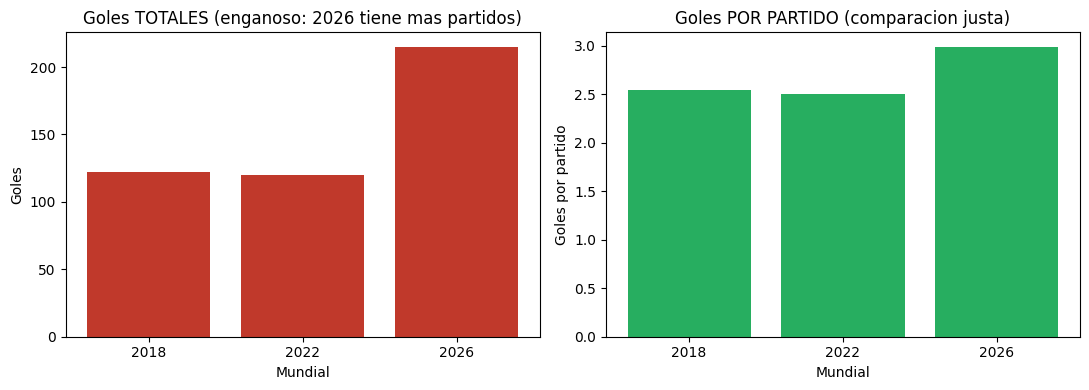

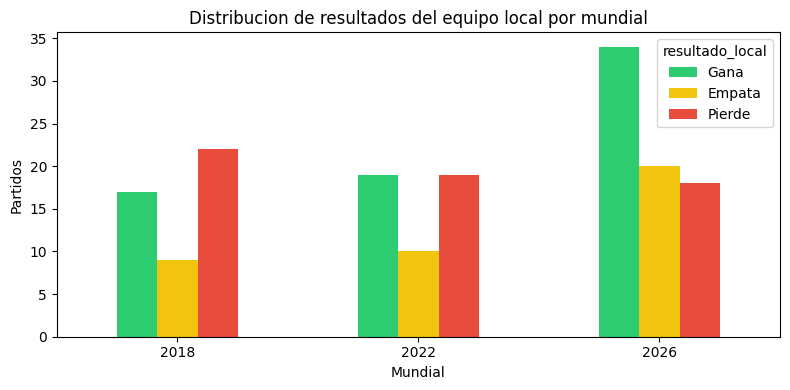

In [10]:
# Tabla comparativa por torneo. La clave: 2026 tiene 72 partidos y 2018/2022 solo 48,
# por eso NO comparamos solo goles totales, sino tasas (goles por partido, % empates).
comparacion = partidos.groupby('mundial').agg(
    partidos=('partido_id', 'count'),
    goles=('goles_totales', 'sum'),
    empates=('resultado_local', lambda s: (s == 'Empata').sum()),
    victorias_anfitrion=('local_es_anfitrion', lambda s: 0),  # se rellena abajo
).reset_index()
comparacion['goles_por_partido'] = (comparacion['goles'] / comparacion['partidos']).round(2)
comparacion['porcentaje_empates'] = (100 * comparacion['empates'] / comparacion['partidos']).round(1)
# % de partidos con mas de 2.5 goles.
comparacion['pct_mas_2_5'] = partidos.groupby('mundial')['goles_totales'].apply(
    lambda s: 100 * (s > 2.5).mean()).round(1).values
# % de victorias del anfitrion (sobre los partidos que jugo como local).
def pct_victoria_anfitrion(m):
    loc = partidos[(partidos.mundial == m) & (partidos.local_es_anfitrion)]
    return round(100 * (loc['resultado_local'] == 'Gana').mean(), 1) if len(loc) else np.nan
comparacion['pct_victoria_anfitrion'] = comparacion['mundial'].map(pct_victoria_anfitrion)
comparacion = comparacion.drop(columns='victorias_anfitrion')
display(comparacion)

# --- Grafico 1: goles totales vs goles por partido (la comparacion enganosa vs la justa) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(comparacion['mundial'].astype(str), comparacion['goles'], color='#c0392b')
ax1.set_title('Goles TOTALES (enganoso: 2026 tiene mas partidos)')
ax1.set_xlabel('Mundial'); ax1.set_ylabel('Goles')
ax2.bar(comparacion['mundial'].astype(str), comparacion['goles_por_partido'], color='#27ae60')
ax2.set_title('Goles POR PARTIDO (comparacion justa)')
ax2.set_xlabel('Mundial'); ax2.set_ylabel('Goles por partido')
plt.tight_layout(); plt.show()

# --- Grafico 2: distribucion de resultados del local por mundial ---
dist = (partidos.groupby(['mundial', 'resultado_local']).size()
        .unstack(fill_value=0)[['Gana', 'Empata', 'Pierde']])
dist.plot(kind='bar', figsize=(8, 4), color=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.title('Distribucion de resultados del equipo local por mundial')
plt.xlabel('Mundial'); plt.ylabel('Partidos'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## Tabla por equipo

In [11]:
# Convertimos cada partido en DOS apariciones de equipo (una como local, otra como visitante)
# para poder calcular la tabla de posiciones de cada seleccion.
loc = partidos.rename(columns={
    'equipo_local': 'equipo', 'goles_local': 'GF', 'goles_visitante': 'GC'})[
    ['mundial', 'grupo', 'equipo', 'GF', 'GC', 'puntos_local']].rename(columns={'puntos_local': 'PTS'})
vis = partidos.copy()
vis['PTS'] = vis['puntos_local'].map({3: 0, 1: 1, 0: 3})  # invertimos los puntos para el visitante
vis = vis.rename(columns={
    'equipo_visitante': 'equipo', 'goles_visitante': 'GF', 'goles_local': 'GC'})[
    ['mundial', 'grupo', 'equipo', 'GF', 'GC', 'PTS']]
apariciones = pd.concat([loc, vis], ignore_index=True)
apariciones['PG'] = (apariciones['GF'] > apariciones['GC']).astype(int)
apariciones['PE'] = (apariciones['GF'] == apariciones['GC']).astype(int)
apariciones['PP'] = (apariciones['GF'] < apariciones['GC']).astype(int)

tabla_equipos = apariciones.groupby(['mundial', 'grupo', 'equipo']).agg(
    PJ=('equipo', 'count'), PG=('PG', 'sum'), PE=('PE', 'sum'), PP=('PP', 'sum'),
    GF=('GF', 'sum'), GC=('GC', 'sum'), PTS=('PTS', 'sum')).reset_index()
tabla_equipos['DG'] = tabla_equipos['GF'] - tabla_equipos['GC']
tabla_equipos['pts_por_partido'] = (tabla_equipos['PTS'] / tabla_equipos['PJ']).round(2)
tabla_equipos = tabla_equipos.sort_values(['mundial', 'grupo', 'PTS', 'DG'],
                                          ascending=[True, True, False, False])

# Equipo con mejor diferencia de goles en cada torneo.
print('Mejor diferencia de goles por torneo:')
mejor = tabla_equipos.loc[tabla_equipos.groupby('mundial')['DG'].idxmax()]
print(mejor[['mundial', 'equipo', 'DG', 'PTS']].to_string(index=False))
tabla_equipos.head(12)

Mejor diferencia de goles por torneo:
 mundial  equipo  DG  PTS
    2018 Belgium   7    9
    2022 England   7    7
    2026  France   8    9


,mundial,grupo,equipo,PJ,PG,PE,PP,GF,GC,PTS,DG,pts_por_partido
3,2018,A,Uruguay,3,3,0,0,5,0,9,5,3.00
1,2018,A,Russia,3,2,0,1,8,4,6,4,2.00
2,2018,A,Saudi Arabia,3,1,0,2,2,7,3,-5,1.00
0,2018,A,Egypt,3,0,0,3,2,6,0,-4,0.00
6,2018,B,Portugal,3,1,2,0,5,4,5,1,1.67
7,2018,B,Spain,3,1,2,0,6,5,5,1,1.67
4,2018,B,Iran,3,1,1,1,2,2,4,0,1.33
5,2018,B,Morocco,3,0,1,2,2,4,1,-2,0.33
10,2018,C,France,3,2,1,0,3,1,7,2,2.33
9,2018,C,Denmark,3,1,2,0,2,1,5,1,1.67


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [12]:
def construir_variables_previas(partidos):
    """Para cada partido guarda los promedios de cada equipo calculados SOLO con los
    partidos anteriores (dentro del mismo torneo). Asi evitamos la fuga de informacion:
    nunca usamos datos que ocurrieron durante o despues del partido a predecir."""
    filas = []
    for mundial, g in partidos.groupby('mundial'):
        g = g.sort_values(['jornada', 'partido_id'])  # orden cronologico
        est = {}  # equipo -> acumulados hasta AHORA

        def promedios_previos(t):
            e = est.get(t)
            if not e or e['PJ'] == 0:
                return 0.0, 0.0, 0.0  # sin historial (jornada 1) -> 0
            return e['pts'] / e['PJ'], (e['GF'] - e['GC']) / e['PJ'], e['GF'] / e['PJ']

        for _, r in g.iterrows():
            lp, lgd, lgf = promedios_previos(r['equipo_local'])
            vp, vgd, vgf = promedios_previos(r['equipo_visitante'])
            filas.append({**r.to_dict(),
                          'local_pts_prom_pre': lp, 'visita_pts_prom_pre': vp,
                          'local_gd_prom_pre': lgd, 'visita_gd_prom_pre': vgd,
                          'local_gf_prom_pre': lgf, 'visita_gf_prom_pre': vgf})
            # AHORA si actualizamos con el resultado del partido actual (para los siguientes).
            pts_vis = {3: 0, 1: 1, 0: 3}[r['puntos_local']]
            for t, gf, gc, pts in [
                    (r['equipo_local'], r['goles_local'], r['goles_visitante'], r['puntos_local']),
                    (r['equipo_visitante'], r['goles_visitante'], r['goles_local'], pts_vis)]:
                e = est.setdefault(t, {'PJ': 0, 'pts': 0, 'GF': 0, 'GC': 0})
                e['PJ'] += 1; e['pts'] += pts; e['GF'] += int(gf); e['GC'] += int(gc)
    return pd.DataFrame(filas)

features_df = construir_variables_previas(partidos)
features_df[['jornada', 'equipo_local', 'equipo_visitante',
             'local_pts_prom_pre', 'visita_pts_prom_pre', 'resultado_local']].head(8)

,jornada,equipo_local,equipo_visitante,local_pts_prom_pre,visita_pts_prom_pre,resultado_local
0,1,Russia,Saudi Arabia,0.0,0.0,Gana
1,1,Egypt,Uruguay,0.0,0.0,Pierde
2,1,Morocco,Iran,0.0,0.0,Pierde
3,1,Portugal,Spain,0.0,0.0,Empata
4,1,France,Australia,0.0,0.0,Gana
5,1,Argentina,Iceland,0.0,0.0,Empata
6,1,Peru,Denmark,0.0,0.0,Pierde
7,1,Croatia,Nigeria,0.0,0.0,Gana


## Entrenamiento y prueba

Linea base (predecir siempre "Pierde"): accuracy = 0.250
Arbol de decision: accuracy = 0.347


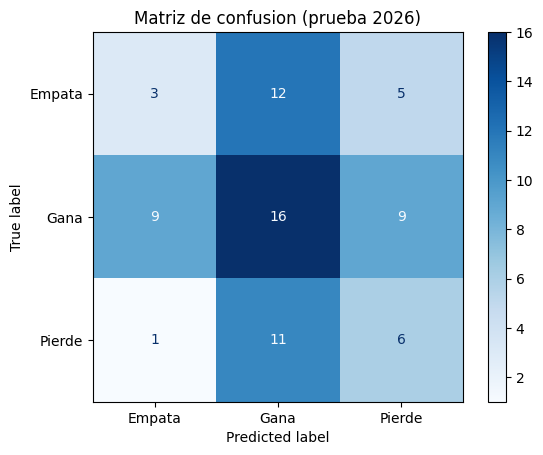


Importancia de variables:
  visita_pts_prom_pre      0.229
  local_gf_prom_pre        0.176
  local_gd_prom_pre        0.160
  local_pts_prom_pre       0.159
  visita_gf_prom_pre       0.140
  jornada                  0.136
  visita_gd_prom_pre       0.000
  local_es_anfitrion       0.000
  visitante_es_anfitrion   0.000


In [13]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

datos = features_df.copy()
# Los booleanos de anfitrion a 0/1; los promedios inexistentes ya salen como 0.
datos['local_es_anfitrion'] = datos['local_es_anfitrion'].astype(int)
datos['visitante_es_anfitrion'] = datos['visitante_es_anfitrion'].astype(int)
datos[features] = datos[features].fillna(0)

# Entrenamiento = 2018 + 2022 ; Prueba = 2026.
train = datos[datos['mundial'].isin([2018, 2022])]
test = datos[datos['mundial'] == 2026]
X_train, y_train = train[features], train['resultado_local']
X_test, y_test = test[features], test['resultado_local']

# Linea base: predecir siempre la clase mas frecuente del entrenamiento.
clase_base = y_train.value_counts().idxmax()
acc_base = (y_test == clase_base).mean()
print(f'Linea base (predecir siempre "{clase_base}"): accuracy = {acc_base:.3f}')

# Arbol de decision.
arbol = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
arbol.fit(X_train, y_train)
pred = arbol.predict(X_test)
print(f'Arbol de decision: accuracy = {accuracy_score(y_test, pred):.3f}')

# Matriz de confusion.
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=arbol.classes_,
                                        cmap='Blues')
plt.title('Matriz de confusion (prueba 2026)')
plt.show()

# Que variables uso el arbol.
print('\nImportancia de variables:')
for f, imp in sorted(zip(features, arbol.feature_importances_), key=lambda t: -t[1]):
    print(f'  {f:24} {imp:.3f}')

## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.

In [14]:
# EXPERIMENTO DE FUGA: agregamos a proposito los goles del propio partido.
# Estas variables NO se conocen antes de jugar -> son "trampa".
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']

arbol_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
arbol_fuga.fit(train[features_fuga], y_train)
pred_fuga = arbol_fuga.predict(test[features_fuga])
acc_fuga = accuracy_score(y_test, pred_fuga)

print(f'Accuracy SIN fuga (modelo honesto): {accuracy_score(y_test, pred):.3f}')
print(f'Accuracy CON fuga (goles del partido): {acc_fuga:.3f}')
print(f'Linea base: {acc_base:.3f}')
print('\nEl salto a ~1.0 no significa un buen modelo: la diferencia_goles YA contiene')
print('el resultado (si diferencia_goles > 0 el local gana). El modelo no "predice",')
print('esta copiando la respuesta. Eso es fuga de informacion (data leakage).')

Accuracy SIN fuga (modelo honesto): 0.347
Accuracy CON fuga (goles del partido): 1.000
Linea base: 0.250

El salto a ~1.0 no significa un buen modelo: la diferencia_goles YA contiene
el resultado (si diferencia_goles > 0 el local gana). El modelo no "predice",
esta copiando la respuesta. Eso es fuga de informacion (data leakage).


## Reflexión final

Responde:

- ¿Qué problema de calidad fue el más difícil?
- ¿Qué decisión de limpieza podría cambiar los resultados?
- ¿Por qué 2026 debe compararse mediante tasas?
- ¿El árbol supera la línea base?
- ¿Qué variables reales agregarías para mejorar una predicción?
- ¿Por qué un resultado de 100 % puede ser una señal de alarma?

## Respuestas

**¿Qué problema de calidad fue el más difícil?**
Las **fechas**. Venían en 6 formatos mezclados (ISO, `dd/mm`, `mm/dd`, `dd-mm-yy`, `Jun 16, 2018`) e incluso como **serial de Excel** (`46187`). Lo peor era la ambigüedad `12/06` vs `06/12`: se resolvió eligiendo el candidato que cae **dentro del rango de fechas del torneo**.

**¿Qué decisión de limpieza podría cambiar los resultados?**
Cuando el marcador y los goles separados no coincidían, decidimos **confiar en el marcador**. También **inferimos los grupos faltantes** a partir de los equipos, y marcamos al **anfitrión por nación sede** en vez de fiarnos de las banderas (venían inconsistentes). Otra elección habría dado una base ligeramente distinta.

**¿Por qué 2026 debe compararse mediante tasas?**
Porque tuvo **72 partidos** frente a **48** de 2018/2022. Los goles totales (215 vs 122 vs 120) hacen ver a 2026 como muy goleador, pero al normalizar a **goles por partido** (2.99 vs 2.54 vs 2.50) la diferencia es mucho menor. Comparar totales sería engañoso.

**¿El árbol supera la línea base?**
Sí, pero **por poco**: línea base ≈ **0.25** y árbol ≈ **0.35** de accuracy en 2026. Predecir el fútbol con tan pocos datos previos es difícil; el modelo apenas mejora al "adivinar siempre la clase más común".

**¿Qué variables reales agregarías?**
Ranking FIFA, valor/experiencia del plantel, historial head-to-head, días de descanso, lesiones, localía real (altitud/clima) y forma reciente fuera del torneo.

**¿Por qué un resultado de 100 % puede ser una señal de alarma?**
Porque suele indicar **fuga de información**: al meter `diferencia_goles` el accuracy saltó a **1.0**, pero esa variable **ya contiene la respuesta** (si es positiva, el local ganó). El modelo no predice, **copia el resultado**. En un problema real, un 100 % casi siempre significa que una variable "del futuro" se coló en el entrenamiento.